# Exercise - ANN Multi Input/Output and Hypertuning for SAR Prediction in VHP Head Model (3)

Exercise in the lecture Machine Learning in Electrical Engineering and Information Technology, Prediction of the Specific Absorption Rate (SAR)

* Lecture Period: Summer 2026 ([StudIP](https://e-learning.tuhh.de/studip/dispatch.php/course/details/index/1be148fc0ce85172e3902adf814a909b))
* Institute: Institut für Theoretische Elektrotechnik ([TET](https://www.tet.tuhh.de/en/))
* University: Hamburg University of Technology ([TUHH](https://www.tuhh.de/tuhh/en/startpage))
* Exercise Supervisor: Malte Thode


The third part of the exercise is about the prediction of the Specific Absorption Rate (SAR) inside a human head model. The human head model consists of multiple tissues that vary in their electric properties. The difference from exercise two is that here the prediction is to be carried out for multiple tissues simultaneously and ANN parameters are tunned for some comparison with previous results before hypertuning.

|||
|:-:|:-:|
|<img title="head exposed to fields" src='figures/model8_2.PNG' width='500'/>|<img title="tissues of the human head model" src='figures/SAR_VHP.png' width='500'/>|
|**VHP Head Model**|**SAR Distribution using FEM Solver**|

### This notebook is structured as follows:
* Loading of required python modules, including a helper module
* Loading the data from the specified CSV file
* Choosing input and output features
* Scaling the data
* Training neural networks
* Evaluating neural networks 

### How to work with the notebook

Each section consists of 2 to 3 cells. The first cell is an introduction to the section and explains the behavior of the following cells. Settings or variables are set in the following cell. Make your settings as you want and run the cell. The cell after is a *code cell*. You do not need to make any settings here, just run the code.

|-|
|:-:|
|<img title="How to Work with the Notebook!" src='figures/cell_setup_2.png' width='700'/>|
|**How to work with the Notebook!**|

#### Module Import
**Modules** are imported, which have to be available to the python interpreter.  
**helper_functions (hp)** is a module in the working directory providing some functions making the notebook more tidy.

**Module Links for Further Information:**
* [pandas](https://pandas.pydata.org/)
* [numpy](https://numpy.org/)
* [matplotlib](https://matplotlib.org/)
* [pickle](https://docs.python.org/3/library/pickle.html)
* [scikit-learn](https://scikit-learn.org/stable/index.html)

In [1]:
# Required modules
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import TransformedTargetRegressor
from sklearn.inspection import permutation_importance
from scipy.stats import pearsonr
from IPython.display import display, Markdown
from matplotlib import pyplot as plt
import sklearn.metrics as sm
import pandas as pd
import numpy as np
import warnings

warnings.filterwarnings("ignore")


#### Load Data from Working Directory

From the local directory the CSV file is loaded. The electromagntic properties of the different tissues are varied and given in the table. The ***conductivity*** and ***relative permitivitty*** of each tissue represent the ***input features***. The resulting ***SAR*** in the different tissues after simulation represent the ***output*** features.

All data samples are split in **Test** and **Train** data before any operations (scaling, ...) are performed.  

**Variables:**
* *test_size* &rarr; share of data used for testing the trained neural network
* *file_name* &rarr; file containing the data

In [2]:
# Reproducible experiment settings
test_size = 0.20
random_state = 42
file_name = "data/task_3.csv"


In [3]:
# Load and inspect the unchanged FEM data.
data_set = pd.read_csv(file_name)
pd.set_option("display.max_columns", None)

input_columns = [c for c in data_set.columns if c.startswith(("Eps_", "Cond_"))]
sar_columns_wkg = [
    c for c in data_set.columns
    if c.startswith("SAR_") and not c.startswith("SAR_max")
]

print("Dataset shape:", data_set.shape)
display(data_set.head())
print("All column names:")
print(data_set.columns.tolist())
print("Number of samples:", data_set.shape[0])
print("Number of input columns:", len(input_columns))
print("Number of tissue SAR output columns:", len(sar_columns_wkg))
print("Excluded from Task 3 outputs:", [c for c in data_set.columns if c.startswith("SAR_max")])

assert data_set.shape[0] == 500
assert len(input_columns) == 28
assert len(sar_columns_wkg) == 14


Dataset shape: (500, 43)


,Eps_blood,Eps_bodyAverage,Eps_boneCortical,Eps_brainGreyMatter,Eps_brainWhiteMatter,Eps_cartilage,Eps_cerebellum,Eps_cerebrospinalFluid,Eps_eyeVitrousHumor,Eps_fatAverageInfiltrated,Eps_nerve,Eps_skin,Eps_tongue,Eps_tooth,Cond_blood(S/m),Cond_bodyAverage(S/m),Cond_boneCortical(S/m),Cond_brainGreyMatter(S/m),Cond_brainWhiteMatter(S/m),Cond_cartilage(S/m),Cond_cerebellum(S/m),Cond_cerebrospinalFluid(S/m),Cond_eyeVitrousHumor(S/m),Cond_fatAverageInfiltrated(S/m),Cond_nerve(S/m),Cond_skin(S/m),Cond_tongue(S/m),Cond_tooth(S/m),SAR_blood(W/kG),SAR_bodyAverage(W/kG),SAR_boneCortical(W/kG),SAR_brainGreyMatter(W/kG),SAR_brainWhiteMatter(W/kG),SAR_cartilage(W/kG),SAR_cerebellum(W/kG),SAR_cerebrospinalFluid(W/kG),SAR_eyeVitrousHumor(W/kG),SAR_fatAverageInfiltrated(W/kG),SAR_nerve(W/kG),SAR_skin(W/kG),SAR_tongue(W/kG),SAR_tooth(W/kG),SAR_max(W/kG)
0,213.304441,137.340829,27.261918,248.374777,171.316061,128.622449,349.622381,92.623836,72.774791,27.869940,121.905593,327.059156,173.424657,31.422336,1.026077,0.627977,0.039758,0.281984,0.189893,0.401758,0.491994,2.072056,1.513320,0.052011,0.228942,0.262527,0.652324,0.041293,0.000751,0.000354,0.000195,0.000196,0.000150,0.002212,0.000384,0.001849,0.000057,0.000446,0.000229,0.000401,0.000140,0.000007,0.002212
1,230.581074,120.815896,34.940186,225.366658,149.852035,130.371693,355.144636,114.894013,63.531107,24.301469,127.157757,304.409876,180.859730,31.401085,0.990097,0.542837,0.043061,0.301486,0.159592,0.405785,0.446913,2.141811,1.690317,0.055034,0.258752,0.271986,0.592679,0.044412,0.000775,0.000344,0.000181,0.000203,0.000136,0.002563,0.000369,0.001866,0.000045,0.000435,0.000263,0.000398,0.000147,0.000009,0.002563
2,227.977126,126.028505,32.462032,228.303351,168.611134,139.595331,383.033851,105.327273,78.034323,28.728686,129.456714,263.174573,144.174667,28.614143,1.064887,0.688818,0.041371,0.301067,0.154175,0.400450,0.437590,1.945106,1.599282,0.054454,0.266583,0.243809,0.505471,0.051320,0.000737,0.000361,0.000183,0.000214,0.000137,0.002019,0.000365,0.001804,0.000062,0.000424,0.000247,0.000362,0.000122,0.000009,0.002019
3,187.693142,130.005210,27.309981,246.363504,166.130195,146.474017,381.715258,103.740564,78.283802,28.668307,132.445628,313.509316,141.242928,30.285059,1.249235,0.677501,0.044420,0.311940,0.162479,0.334472,0.440733,1.997302,1.356690,0.057816,0.268330,0.259650,0.597291,0.039526,0.000779,0.000357,0.000190,0.000211,0.000139,0.001767,0.000369,0.001791,0.000063,0.000406,0.000249,0.000359,0.000132,0.000007,0.001791
4,193.239816,125.495530,30.265481,252.820374,173.361470,150.386422,353.345159,93.888970,72.768746,22.408424,127.698439,291.681333,176.779322,34.009850,1.099634,0.655387,0.038846,0.375926,0.164448,0.369080,0.442055,2.167626,1.550480,0.050380,0.218862,0.266649,0.643891,0.039692,0.000767,0.000357,0.000192,0.000221,0.000127,0.002030,0.000384,0.001765,0.000066,0.000453,0.000221,0.000379,0.000140,0.000008,0.002030


All column names:
['Eps_blood', 'Eps_bodyAverage', 'Eps_boneCortical', 'Eps_brainGreyMatter', 'Eps_brainWhiteMatter', 'Eps_cartilage', 'Eps_cerebellum', 'Eps_cerebrospinalFluid', 'Eps_eyeVitrousHumor', 'Eps_fatAverageInfiltrated', 'Eps_nerve', 'Eps_skin', 'Eps_tongue', 'Eps_tooth', 'Cond_blood(S/m)', 'Cond_bodyAverage(S/m)', 'Cond_boneCortical(S/m)', 'Cond_brainGreyMatter(S/m)', 'Cond_brainWhiteMatter(S/m)', 'Cond_cartilage(S/m)', 'Cond_cerebellum(S/m)', 'Cond_cerebrospinalFluid(S/m)', 'Cond_eyeVitrousHumor(S/m)', 'Cond_fatAverageInfiltrated(S/m)', 'Cond_nerve(S/m)', 'Cond_skin(S/m)', 'Cond_tongue(S/m)', 'Cond_tooth(S/m)', 'SAR_blood(W/kG)', 'SAR_bodyAverage(W/kG)', 'SAR_boneCortical(W/kG)', 'SAR_brainGreyMatter(W/kG)', 'SAR_brainWhiteMatter(W/kG)', 'SAR_cartilage(W/kG)', 'SAR_cerebellum(W/kG)', 'SAR_cerebrospinalFluid(W/kG)', 'SAR_eyeVitrousHumor(W/kG)', 'SAR_fatAverageInfiltrated(W/kG)', 'SAR_nerve(W/kG)', 'SAR_skin(W/kG)', 'SAR_tongue(W/kG)', 'SAR_tooth(W/kG)', 'SAR_max(W/kG)']
Numb

#### Choosing input and all 14 output features

Task 3 predicts all tissue SAR values simultaneously: **28 material-property inputs -> 14 tissue SAR outputs**. Columns are selected by their names, and `SAR_max` is explicitly excluded.


In [4]:
# Select inputs programmatically and convert only the 14 targets from W/kg to mW/kg.
X = data_set.loc[:, input_columns].astype(float).copy()
Y = data_set.loc[:, sar_columns_wkg].astype(float).copy() * 1000.0
output_columns = [c.replace("(W/kG)", "(mW/kg)") for c in sar_columns_wkg]
Y.columns = output_columns
tissue_names = [c.removeprefix("SAR_").replace("(mW/kg)", "") for c in output_columns]

assert X.shape == (500, 28)
assert Y.shape == (500, 14)
assert not any(c.startswith("SAR_") for c in X.columns)

# One split is shared by every experiment. Test data are never used for tuning.
train_input, test_input, train_output, test_output = train_test_split(
    X, Y, test_size=test_size, shuffle=True, random_state=random_state
)

print("X shape:", X.shape)
print("Y shape:", Y.shape)
print("Training shapes:", train_input.shape, train_output.shape)
print("Test shapes:", test_input.shape, test_output.shape)


X shape: (500, 28)
Y shape: (500, 14)
Training shapes: (400, 28) (400, 14)
Test shapes: (100, 28) (100, 14)


#### Scaling of Data
A scaler is used to scale the input features. The scaler is fitted on the train data only, and applied to the train and test data. Feature scaling usually makes the training faster. It prevents the optimization from getting stuck in local optima.

In [5]:
# Lecture-style preprocessing: fit only on training inputs to avoid leakage.
input_scaler = StandardScaler()
input_scaler.fit(train_input)
train_input_scaled = input_scaler.transform(train_input)
test_input_scaled = input_scaler.transform(test_input)


#### Training Neural Networks

**Sklearn** provides methods to train different kind of machine learning tools e.g. neural networks. To predict the SAR values inside the sphere, we have to define a regressor. The topology and training parameters of the neural network are defined and set before train.

**Variables:**
* *hidden_layer_sizes* &rarr; topologies of neural networks
* *solver* &rarr; solver used during training the neural network and optimizing the weights
* *learning_rate_init* &rarr; initial learning rates used for the solver
* *learning_rate* &rarr; type of learning rate
* *max_iter* &rarr; maximum number of iterations before termination of the training 
* *activation* &rarr; activation function for the hidden layer.
* *alpha* &rarr; strength of the L2 regularization term. 
* *n_iter_no_change* &rarr; maximum number of epochs to not meet tol improvement.
* *early_stopping* &rarr; Whether to use early stopping to terminate training when validation score is not improving

Possible parameters can be identified on https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPRegressor.html


In [6]:
# Original baseline: 28 -> 5 -> 14, with unscaled SAR targets in mW/kg.
baseline_params = {
    "hidden_layer_sizes": (5,),
    "learning_rate_init": 1e-2,
    "solver": "adam",
    "max_iter": 20000,
    "activation": "tanh",
    "alpha": 0.0001,
    "n_iter_no_change": 50,
    "tol": 1e-5,
    "early_stopping": True,
    "random_state": random_state,
}
print("Baseline parameters:", baseline_params)
print("Baseline architecture: 28 -> 5 -> 14")


Baseline parameters: {'hidden_layer_sizes': (5,), 'learning_rate_init': 0.01, 'solver': 'adam', 'max_iter': 20000, 'activation': 'tanh', 'alpha': 0.0001, 'n_iter_no_change': 50, 'tol': 1e-05, 'early_stopping': True, 'random_state': 42}
Baseline architecture: 28 -> 5 -> 14


In [7]:
# Train the lecture-style baseline only on the training set.
NN = MLPRegressor(**baseline_params)
NN.fit(train_input_scaled, train_output)


MLPRegressor(activation='tanh', early_stopping=True, hidden_layer_sizes=(5,),
             learning_rate_init=0.01, max_iter=20000, n_iter_no_change=50,
             random_state=42, tol=1e-05)

#### Evaluating Neural Network Training

After training the neural networks, the networks are evaluated. There are many different metrics to evaluate the performance of the neural network including scores and errors (mean squared error, mean absolute error, ...). Plots of the loss curve and prediction of the test samples give a better insight on the performance.

* *Training and testing scores* &rarr; coefficient of determination R² that measures how well a statistical model predicts an outcome.
* *Mean absolute error* &rarr; average of the absolute errors between predictions and actual values.
* *Mean squared error* &rarr; average of the squares of the errors between predictions and actual values.
* *Median absolute error* &rarr; median of the absolute errors between predictions and actual values.
* *explained variance score* &rarr; measure of the dispersion of errors.
* *most widely used correlation* &rarr; coefficient to measure a linear correlation.

More informations on metrics and scoring on https://scikit-learn.org/stable/modules/model_evaluation.html#model-evaluation

#### Output Prediction and Scores Calculation
Predict the outputs and calculate the error and scores for the prediction

In [8]:
# Predict before any evaluation or plot.
baseline_train_pred = NN.predict(train_input_scaled)
baseline_pred = NN.predict(test_input_scaled)
print("Y_test shape:", test_output.shape)
print("Baseline prediction shape:", baseline_pred.shape)
assert baseline_pred.shape == (100, 14)


Y_test shape: (100, 14)
Baseline prediction shape: (100, 14)


In [9]:
# Reusable macro-average and per-tissue evaluation.
def evaluate_multioutput(y_true, y_pred, y_train_true, y_train_pred, label):
    rows = []
    for j, tissue in enumerate(tissue_names):
        yt = np.asarray(y_true)[:, j]
        yp = np.asarray(y_pred)[:, j]
        corr = pearsonr(yt, yp)[0]
        rows.append({
            "Tissue": tissue,
            "R2": sm.r2_score(yt, yp),
            "MAE_mW/kg": sm.mean_absolute_error(yt, yp),
            "MSE_(mW/kg)^2": sm.mean_squared_error(yt, yp),
            "MedAE_mW/kg": sm.median_absolute_error(yt, yp),
            "Explained Variance": sm.explained_variance_score(yt, yp),
            "Pearson correlation": corr,
        })
    table = pd.DataFrame(rows)
    summary = {
        "Model": label,
        "R2_train": sm.r2_score(y_train_true, y_train_pred, multioutput="uniform_average"),
        "Mean test R2": table["R2"].mean(),
        "Median test R2": table["R2"].median(),
        "Mean MAE": table["MAE_mW/kg"].mean(),
        "Mean MSE": table["MSE_(mW/kg)^2"].mean(),
        "Mean MedAE": table["MedAE_mW/kg"].mean(),
        "Mean EV": table["Explained Variance"].mean(),
        "Mean Pearson": table["Pearson correlation"].mean(),
        "Best tissue": table.loc[table["R2"].idxmax(), "Tissue"],
        "Best R2": table["R2"].max(),
        "Worst tissue": table.loc[table["R2"].idxmin(), "Tissue"],
        "Worst R2": table["R2"].min(),
    }
    return table, summary

baseline_tissue_metrics, baseline_summary = evaluate_multioutput(
    test_output, baseline_pred, train_output, baseline_train_pred, "Baseline ANN"
)
display(baseline_tissue_metrics.style.format(precision=6))
print("Baseline macro-average metrics:")
for key, value in baseline_summary.items():
    print(f"{key}: {value:.6f}" if isinstance(value, float) else f"{key}: {value}")


,Tissue,R2,MAE_mW/kg,MSE_(mW/kg)^2,MedAE_mW/kg,Explained Variance,Pearson correlation
0,blood,0.950738,0.004541,0.000031,0.004101,0.950754,0.975069
1,bodyAverage,0.672667,0.003223,0.000015,0.003119,0.676456,0.822471
2,boneCortical,-0.113281,0.004261,0.000026,0.004076,-0.105929,-0.007967
3,brainGreyMatter,0.782477,0.004491,0.000030,0.003830,0.782480,0.885695
4,brainWhiteMatter,0.179891,0.007213,0.000076,0.006172,0.214363,0.479393
5,cartilage,0.996067,0.012000,0.000221,0.010830,0.996070,0.998058
6,cerebellum,0.421103,0.009452,0.000144,0.008559,0.424092,0.660479
7,cerebrospinalFluid,0.992514,0.006097,0.000061,0.004608,0.992514,0.996396
8,eyeVitrousHumor,0.679905,0.003756,0.000020,0.003166,0.680085,0.824963
9,fatAverageInfiltrated,0.920514,0.004222,0.000028,0.003421,0.921476,0.961472


Baseline macro-average metrics:
Model: Baseline ANN
R2_train: 0.611425
Mean test R2: 0.580189
Median test R2: 0.676286
Mean MAE: 0.005665
Mean MSE: 0.000065
Mean MedAE: 0.004925
Mean EV: 0.586976
Mean Pearson: 0.718890
Best tissue: cartilage
Best R2: 0.996067
Worst tissue: boneCortical
Worst R2: -0.113281


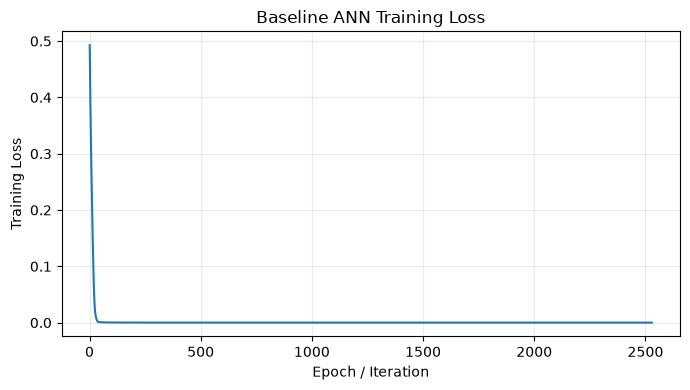

In [10]:
# loss_curve_ is training loss, not test MSE.
plt.figure(figsize=(7, 4))
plt.plot(np.arange(1, len(NN.loss_curve_) + 1), NN.loss_curve_)
plt.xlabel("Epoch / Iteration")
plt.ylabel("Training Loss")
plt.title("Baseline ANN Training Loss")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()


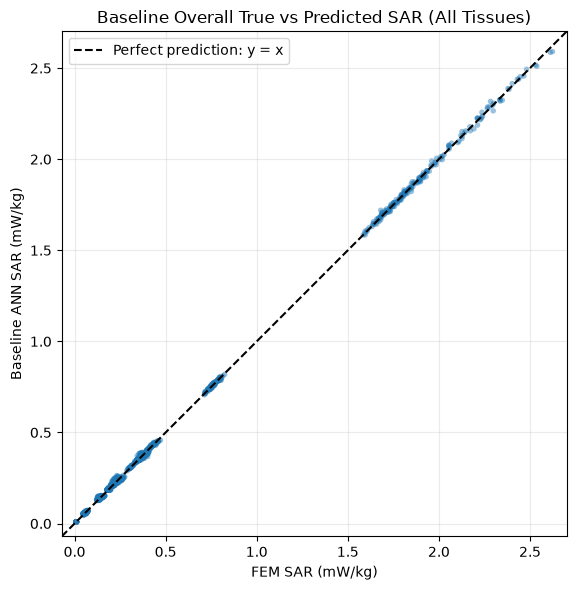

In [11]:
# Overall visualization only: all 14 tissues are flattened into one scatter plot.
true_flat = test_output.to_numpy().ravel()
baseline_flat = baseline_pred.ravel()
lo = min(true_flat.min(), baseline_flat.min())
hi = max(true_flat.max(), baseline_flat.max())
pad = 0.03 * (hi - lo)
limits = (lo - pad, hi + pad)

plt.figure(figsize=(6, 6))
plt.scatter(true_flat, baseline_flat, s=16, alpha=0.45, edgecolor="none")
plt.plot(limits, limits, "k--", label="Perfect prediction: y = x")
plt.xlim(limits); plt.ylim(limits)
plt.gca().set_aspect("equal", adjustable="box")
plt.xlabel("FEM SAR (mW/kg)")
plt.ylabel("Baseline ANN SAR (mW/kg)")
plt.title("Baseline Overall True vs Predicted SAR (All Tissues)")
plt.grid(alpha=0.25); plt.legend(); plt.tight_layout(); plt.show()


#### Target Scaling and Hyperparameter Tuning

Model selection uses five-fold cross-validation on the 400 training samples only. Every candidate contains its own `StandardScaler` inside a pipeline, so preprocessing is refitted independently in each fold. A second baseline uses `TransformedTargetRegressor` to standardize all 14 SAR targets inside each training fold and automatically inverse-transform predictions to mW/kg.


In [12]:
# Compare lecture-style and target-scaled baselines using training-only CV.
cv = KFold(n_splits=5, shuffle=True, random_state=random_state)
raw_baseline_cv_model = Pipeline([
    ("input_scaler", StandardScaler()),
    ("mlp", MLPRegressor(**baseline_params)),
])
scaled_baseline_cv_model = TransformedTargetRegressor(
    regressor=Pipeline([
        ("input_scaler", StandardScaler()),
        ("mlp", MLPRegressor(**baseline_params)),
    ]),
    transformer=StandardScaler(),
)

raw_baseline_cv = cross_val_score(
    raw_baseline_cv_model, train_input, train_output, cv=cv, scoring="r2", n_jobs=1
)
scaled_baseline_cv = cross_val_score(
    scaled_baseline_cv_model, train_input, train_output, cv=cv, scoring="r2", n_jobs=1
)
use_target_scaling = scaled_baseline_cv.mean() > raw_baseline_cv.mean()

print(f"Baseline CV R2 without target scaling: {raw_baseline_cv.mean():.6f} +/- {raw_baseline_cv.std():.6f}")
print(f"Baseline CV R2 with target scaling:    {scaled_baseline_cv.mean():.6f} +/- {scaled_baseline_cv.std():.6f}")
print("Selected tuning approach:", "target-scaled" if use_target_scaling else "unscaled-target")


Baseline CV R2 without target scaling: -0.066259 +/- 0.249783
Baseline CV R2 with target scaling:    0.712141 +/- 0.006704
Selected tuning approach: target-scaled


In [13]:
# Leakage-safe randomized search over a reasonable subset of 108 combinations.
base_search_pipeline = Pipeline([
    ("input_scaler", StandardScaler()),
    ("mlp", MLPRegressor(
        solver="adam", max_iter=20000, n_iter_no_change=50, tol=1e-5,
        early_stopping=True, random_state=random_state
    )),
])

if use_target_scaling:
    tuning_estimator = TransformedTargetRegressor(
        regressor=base_search_pipeline, transformer=StandardScaler()
    )
    prefix = "regressor__mlp__"
else:
    tuning_estimator = base_search_pipeline
    prefix = "mlp__"

parameter_distributions = {
    prefix + "hidden_layer_sizes": [(5,), (10,), (15,), (20,), (10, 5),
                                      (20, 10), (10, 10), (20, 20), (10, 10, 10)],
    prefix + "activation": ["tanh", "relu"],
    prefix + "alpha": [1e-5, 1e-4, 1e-3],
    prefix + "learning_rate_init": [1e-3, 1e-2],
}

search = RandomizedSearchCV(
    tuning_estimator,
    param_distributions=parameter_distributions,
    n_iter=24,
    scoring="r2",
    cv=cv,
    random_state=random_state,
    n_jobs=1,
    return_train_score=True,
)
search.fit(train_input, train_output)


RandomizedSearchCV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
                   estimator=TransformedTargetRegressor(regressor=Pipeline(steps=[('input_scaler',
                                                                                   StandardScaler()),
                                                                                  ('mlp',
                                                                                   MLPRegressor(early_stopping=True,
                                                                                                max_iter=20000,
                                                                                                n_iter_no_change=50,
                                                                                                random_state=42,
                                                                                                tol=1e-05))]),
                                                        transformer=StandardScaler()),
                   n_iter=24, n_jobs=1,
                   param_distributions={'regressor__mlp__activation': ['tanh',
                                                                       'relu'],
                                        'regressor__mlp__alpha': [1e-05, 0.0001,
                                                                  0.001],
                                        'regressor__mlp__hidden_layer_sizes': [(5,),
                                                                               (10,),
                                                                               (15,),
                                                                               (20,),
                                                                               (10,
                                                                                5),
                                                                               (20,
                                                                                10),
                                                                               (10,
                                                                                10),
                                                                               (20,
                                                                                20),
                                                                               (10,
                                                                                10,
                                                                                10)],
                                        'regressor__mlp__learning_rate_init': [0.001,
                                                                               0.01]},
                   random_state=42, return_train_score=True, scoring='r2')

#### Retraining The Best Neural Network Training

After the grid search, the best topology and model can be identified. The best model is then retrained for evaluation. 

In [14]:
# Report the training-only model-selection result.
best_params_prefixed = search.best_params_
best_params = {key.replace(prefix, ""): value for key, value in best_params_prefixed.items()}
baseline_cv_for_selected_approach = (
    scaled_baseline_cv.mean() if use_target_scaling else raw_baseline_cv.mean()
)

print(f"Baseline CV R2 (selected scaling approach): {baseline_cv_for_selected_approach:.6f}")
print(f"Best CV R2: {search.best_score_:.6f}")
print("Best hyperparameters:", best_params)
print("Best topology:", best_params["hidden_layer_sizes"])


Baseline CV R2 (selected scaling approach): 0.712141
Best CV R2: 0.992356
Best hyperparameters: {'learning_rate_init': 0.001, 'hidden_layer_sizes': (20,), 'alpha': 0.001, 'activation': 'tanh'}
Best topology: (20,)


In [15]:
# RandomizedSearchCV has already refitted the winner on all 400 training samples.
final_model = search.best_estimator_
final_model.fit(train_input, train_output)

if use_target_scaling:
    final_mlp = final_model.regressor_.named_steps["mlp"]
else:
    final_mlp = final_model.named_steps["mlp"]

hidden_text = " -> ".join(map(str, final_mlp.hidden_layer_sizes))
architecture = f"28 -> {hidden_text} -> 14"
print("Final ANN architecture:", architecture)
print("28 = permittivity and conductivity inputs of 14 tissues")
print("14 = simultaneous tissue SAR outputs")


Final ANN architecture: 28 -> 20 -> 14
28 = permittivity and conductivity inputs of 14 tissues
14 = simultaneous tissue SAR outputs


In [16]:
# Predict the untouched test set only after model selection.
final_train_pred = final_model.predict(train_input)
NN_pred = final_model.predict(test_input)
print("Y_test shape:", test_output.shape)
print("Y_pred shape:", NN_pred.shape)
assert test_output.shape == NN_pred.shape == (100, 14)


Y_test shape: (100, 14)
Y_pred shape: (100, 14)


,Tissue,R2,MAE_mW/kg,MSE_(mW/kg)^2,MedAE_mW/kg,Explained Variance,Pearson correlation
0,blood,0.993092,0.001164,0.000004,0.000698,0.993093,0.996554
1,bodyAverage,0.997087,0.000214,0.000000,0.000141,0.997162,0.998583
2,boneCortical,0.988876,0.000383,0.000000,0.000299,0.989099,0.994538
3,brainGreyMatter,0.996847,0.000544,0.000000,0.000503,0.996850,0.998493
4,brainWhiteMatter,0.997019,0.000411,0.000000,0.000307,0.997024,0.998513
5,cartilage,0.997278,0.009396,0.000153,0.007034,0.997366,0.998691
6,cerebellum,0.995252,0.000844,0.000001,0.000667,0.995258,0.997655
7,cerebrospinalFluid,0.997542,0.003237,0.000020,0.002352,0.997560,0.998881
8,eyeVitrousHumor,0.998353,0.000242,0.000000,0.000189,0.998355,0.999179
9,fatAverageInfiltrated,0.979752,0.001505,0.000007,0.000928,0.980360,0.990137


,Model,R2_train,Mean test R2,Mean MAE,Mean MSE,Mean EV,Mean Pearson
0,Baseline ANN,0.611425,0.580189,0.005665,0.000065,0.586976,0.718890
1,Hypertuned ANN,0.997484,0.993761,0.001455,0.000014,0.993855,0.996964


Final macro-average metrics:
Model: Hypertuned ANN
R2_train: 0.997484
Mean test R2: 0.993761
Median test R2: 0.996613
Mean MAE: 0.001455
Mean MSE: 0.000014
Mean MedAE: 0.001065
Mean EV: 0.993855
Mean Pearson: 0.996964
Best tissue: tongue
Best R2: 0.998581
Worst tissue: fatAverageInfiltrated
Worst R2: 0.979752
The train-test R2 gap is 0.004; there is no obvious severe overfitting.


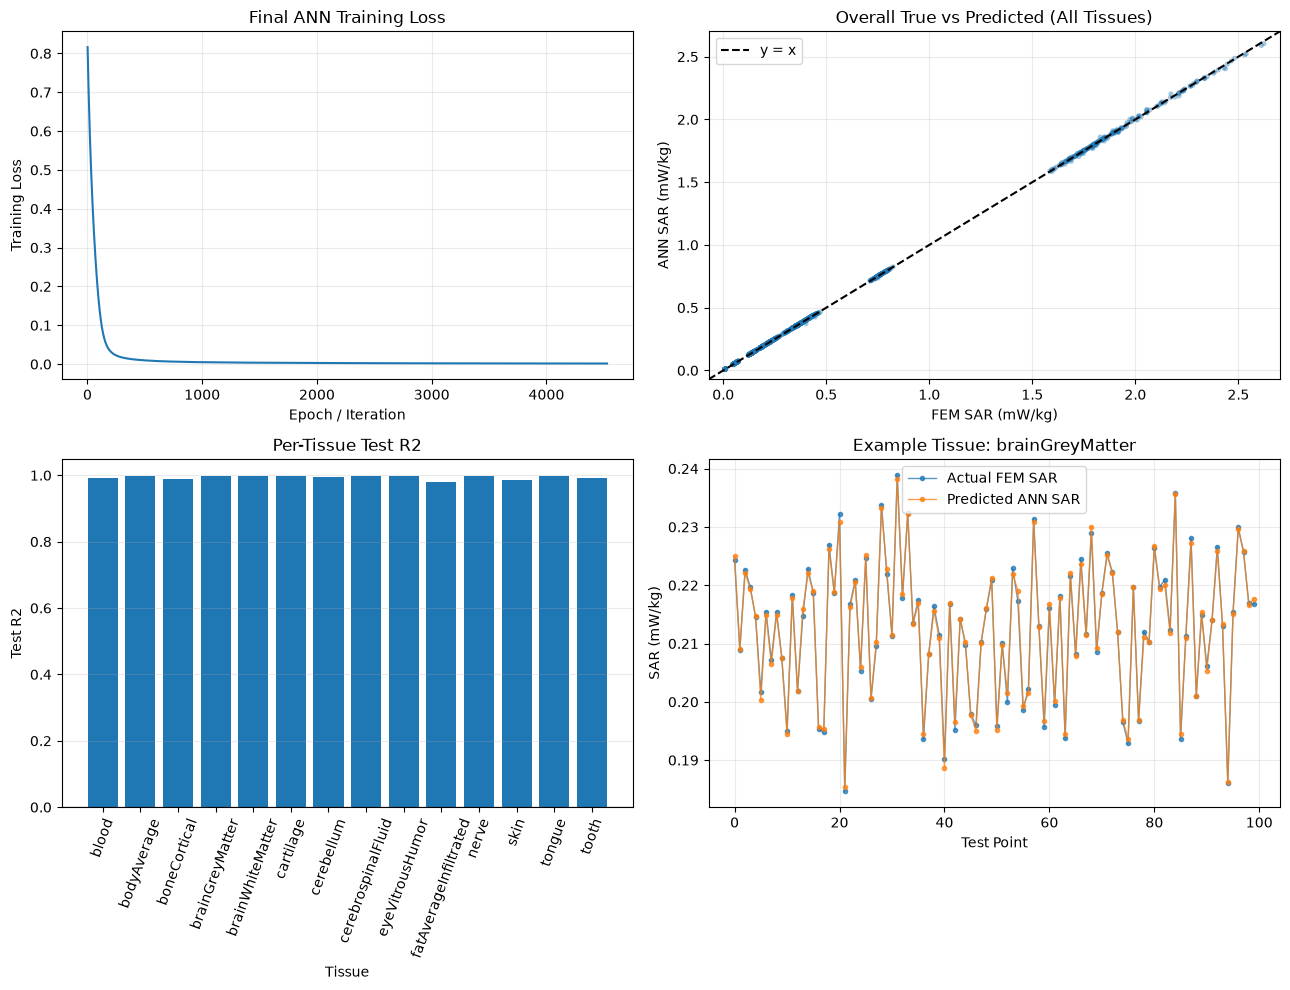

In [17]:
# Final macro-average and per-tissue evaluation.
final_tissue_metrics, final_summary = evaluate_multioutput(
    test_output, NN_pred, train_output, final_train_pred, "Hypertuned ANN"
)
display(final_tissue_metrics.style.format(precision=6))

comparison = pd.DataFrame([baseline_summary, final_summary])[
    ["Model", "R2_train", "Mean test R2", "Mean MAE", "Mean MSE", "Mean EV", "Mean Pearson"]
]
display(comparison.style.format(precision=6))

print("Final macro-average metrics:")
for key, value in final_summary.items():
    print(f"{key}: {value:.6f}" if isinstance(value, float) else f"{key}: {value}")

r2_gap = final_summary["R2_train"] - final_summary["Mean test R2"]
overfit_statement = (
    f"The train-test R2 gap is {r2_gap:.3f}; this suggests appreciable overfitting."
    if r2_gap > 0.10 else
    f"The train-test R2 gap is {r2_gap:.3f}; there is no obvious severe overfitting."
)
print(overfit_statement)

# Required plots for the selected final model.
fig, axes = plt.subplots(2, 2, figsize=(13, 10))

axes[0, 0].plot(np.arange(1, len(final_mlp.loss_curve_) + 1), final_mlp.loss_curve_)
axes[0, 0].set(xlabel="Epoch / Iteration", ylabel="Training Loss", title="Final ANN Training Loss")
axes[0, 0].grid(alpha=0.25)

final_flat = NN_pred.ravel()
lo = min(true_flat.min(), final_flat.min()); hi = max(true_flat.max(), final_flat.max())
pad = 0.03 * (hi - lo); limits = (lo - pad, hi + pad)
axes[0, 1].scatter(true_flat, final_flat, s=14, alpha=0.4, edgecolor="none")
axes[0, 1].plot(limits, limits, "k--", label="y = x")
axes[0, 1].set(xlim=limits, ylim=limits, xlabel="FEM SAR (mW/kg)",
               ylabel="ANN SAR (mW/kg)", title="Overall True vs Predicted (All Tissues)")
axes[0, 1].legend(); axes[0, 1].grid(alpha=0.25)

bar_colors = ["tab:orange" if x < 0 else "tab:blue" for x in final_tissue_metrics["R2"]]
axes[1, 0].bar(tissue_names, final_tissue_metrics["R2"], color=bar_colors)
axes[1, 0].axhline(0, color="black", linewidth=0.8)
axes[1, 0].set(xlabel="Tissue", ylabel="Test R2", title="Per-Tissue Test R2")
axes[1, 0].tick_params(axis="x", rotation=70)
axes[1, 0].grid(axis="y", alpha=0.25)

example_tissue = "brainGreyMatter"
example_index = tissue_names.index(example_tissue)
points = np.arange(len(test_output))
axes[1, 1].plot(points, test_output.iloc[:, example_index], "o-", ms=3, lw=1,
                label="Actual FEM SAR", alpha=0.75)
axes[1, 1].plot(points, NN_pred[:, example_index], "o-", ms=3, lw=1,
                label="Predicted ANN SAR", alpha=0.75)
axes[1, 1].set(xlabel="Test Point", ylabel="SAR (mW/kg)",
               title=f"Example Tissue: {example_tissue}")
axes[1, 1].legend(); axes[1, 1].grid(alpha=0.25)

plt.tight_layout(); plt.show()


#### Guiding Questions, Sensitivity Analysis, and Final Summary

The next cells quantify overall multi-output sensitivity and answer the exercise questions using the measured results.


#### Multi-Output Permutation Sensitivity

Permutation importance measures predictive dependence of the fitted ANN: each input is shuffled and the decrease in mean R² across the 14 outputs is recorded. It does **not** prove physical causality.


,Feature,Permutation importance,Std
0,Cond_bodyAverage(S/m),0.526547,0.055149
1,Cond_cerebrospinalFluid(S/m),0.274814,0.028458
2,Cond_brainGreyMatter(S/m),0.150402,0.017885
3,Cond_skin(S/m),0.113836,0.010588
4,Eps_boneCortical,0.111031,0.013127
5,Cond_fatAverageInfiltrated(S/m),0.108880,0.011005
6,Cond_blood(S/m),0.091118,0.010122
7,Cond_nerve(S/m),0.090897,0.010114
8,Cond_brainWhiteMatter(S/m),0.084748,0.007092
9,Cond_tooth(S/m),0.083803,0.008991


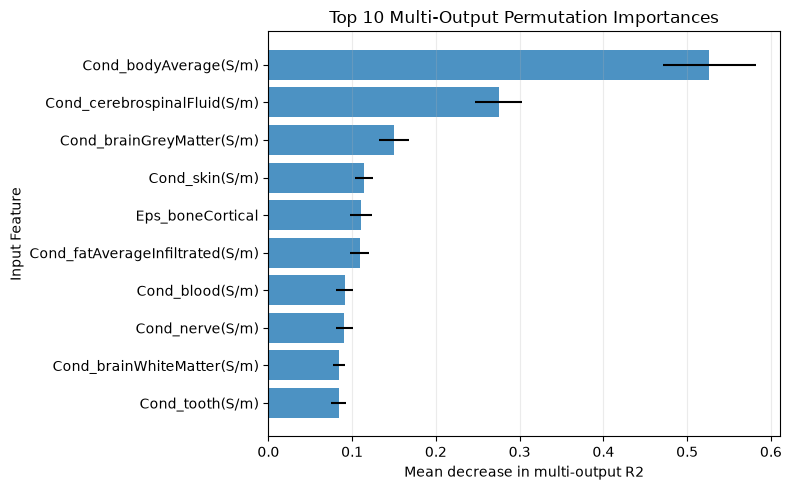

In [18]:
def mean_multioutput_r2(estimator, x_values, y_values):
    return sm.r2_score(y_values, estimator.predict(x_values), multioutput="uniform_average")

importance_result = permutation_importance(
    final_model,
    test_input,
    test_output,
    scoring=mean_multioutput_r2,
    n_repeats=25,
    random_state=random_state,
    n_jobs=1,
)
importance_table = pd.DataFrame({
    "Feature": input_columns,
    "Permutation importance": importance_result.importances_mean,
    "Std": importance_result.importances_std,
}).sort_values("Permutation importance", ascending=False, ignore_index=True)
top_10 = importance_table.head(10)
display(top_10.style.format(precision=6))

plt.figure(figsize=(8, 5))
plot_data = top_10.sort_values("Permutation importance")
plt.barh(plot_data["Feature"], plot_data["Permutation importance"],
         xerr=plot_data["Std"], alpha=0.8)
plt.xlabel("Mean decrease in multi-output R2")
plt.ylabel("Input Feature")
plt.title("Top 10 Multi-Output Permutation Importances")
plt.grid(axis="x", alpha=0.25)
plt.tight_layout(); plt.show()


#### Result-Based Answers and Compact Summary


In [19]:
top_five = importance_table.head(5)["Feature"].tolist()
hypertuning_improved = final_summary["Mean test R2"] > baseline_summary["Mean test R2"]
target_scaling_improved_cv = scaled_baseline_cv.mean() > raw_baseline_cv.mean()

answers = f"""
**Do we need a neural network?**  
Not necessarily. The +/-20% material variation may produce a sufficiently smooth mapping for simpler regressors. The ANN is valuable as a fast nonlinear surrogate for expensive FEM simulations.

**What other methods are possible?**  
Linear regression, polynomial regression, support-vector regression, random forests, and Gaussian-process regression are reasonable alternatives.

**Do we need scaling?**  
Input scaling is recommended for gradient-based MLP training. Target scaling {'improved' if target_scaling_improved_cv else 'did not improve'} mean baseline CV R2 ({scaled_baseline_cv.mean():.6f} versus {raw_baseline_cv.mean():.6f}) and was {'used' if use_target_scaling else 'not used'} in tuning.

**Do we need all inputs?**  
The importance ranking shows unequal predictive dependence, with {', '.join(top_five)} leading overall. A low individual importance does not prove that an input is unnecessary because features can be correlated or interact.

**How do other tissues influence one tissue's SAR?**  
Their permittivity and conductivity modify the internal electric-field distribution, which changes SAR throughout the head model.

**Does splitting affect evaluation?**  
Yes. With 500 samples, different splits can change scores. The fixed seed makes this split reproducible, and five-fold training-only CV gives a more robust selection estimate.

**How was sensitivity implemented?**  
Each test input was shuffled repeatedly while the fitted model stayed fixed. The mean decrease in macro R2 gives multi-output permutation importance; this is predictive dependence, not causality.

**How can multi-output prediction be improved?**  
Suitable topology, tuned activation/learning rate/regularization, proper input and possible target scaling, early stopping, and more representative training data can help. Here the choices were determined by CV rather than assumed.

**Is a special multi-output ANN required?**  
No. `MLPRegressor` supports `y` with shape `(n_samples, n_outputs)` directly, so one network jointly produces all 14 tissue predictions.

**What is the benefit of hypertuning?**  
It systematically compares reproducible ANN configurations on training-only validation folds instead of manually guessing the number of layers and neurons. Here it {'improved' if hypertuning_improved else 'did not improve'} mean test R2 relative to the baseline.

### Compact Final Summary

| Item | Measured result |
|---|---|
| Number of samples | {len(X)} |
| Train/test | {len(train_input)} / {len(test_input)} |
| Inputs / outputs | {X.shape[1]} / {Y.shape[1]} |
| Baseline topology | 28 -> 5 -> 14 |
| Baseline mean test R2 | {baseline_summary['Mean test R2']:.6f} |
| Best topology | {best_params['hidden_layer_sizes']} |
| Best activation | {best_params['activation']} |
| Best alpha | {best_params['alpha']} |
| Best learning rate | {best_params['learning_rate_init']} |
| Best CV R2 | {search.best_score_:.6f} |
| Final mean test R2 | {final_summary['Mean test R2']:.6f} |
| Final mean MAE | {final_summary['Mean MAE']:.6f} mW/kg |
| Final mean MSE | {final_summary['Mean MSE']:.6f} (mW/kg)^2 |
| Final mean EV | {final_summary['Mean EV']:.6f} |
| Final mean Pearson | {final_summary['Mean Pearson']:.6f} |
| Best predicted tissue | {final_summary['Best tissue']} (R2={final_summary['Best R2']:.6f}) |
| Worst predicted tissue | {final_summary['Worst tissue']} (R2={final_summary['Worst R2']:.6f}) |
| Top five inputs | {', '.join(top_five)} |
| Did hypertuning improve test R2? | {'Yes' if hypertuning_improved else 'No'} |
| Did output scaling improve baseline CV? | {'Yes' if target_scaling_improved_cv else 'No'} |
| Overfitting assessment | {overfit_statement} |

Task 2 solved **28 inputs -> 1 SAR output**. Task 3 solves the higher-complexity **28 inputs -> tuned ANN -> 14 simultaneous SAR outputs** problem.
"""
display(Markdown(answers))



**Do we need a neural network?**  
Not necessarily. The +/-20% material variation may produce a sufficiently smooth mapping for simpler regressors. The ANN is valuable as a fast nonlinear surrogate for expensive FEM simulations.

**What other methods are possible?**  
Linear regression, polynomial regression, support-vector regression, random forests, and Gaussian-process regression are reasonable alternatives.

**Do we need scaling?**  
Input scaling is recommended for gradient-based MLP training. Target scaling improved mean baseline CV R2 (0.712141 versus -0.066259) and was used in tuning.

**Do we need all inputs?**  
The importance ranking shows unequal predictive dependence, with Cond_bodyAverage(S/m), Cond_cerebrospinalFluid(S/m), Cond_brainGreyMatter(S/m), Cond_skin(S/m), Eps_boneCortical leading overall. A low individual importance does not prove that an input is unnecessary because features can be correlated or interact.

**How do other tissues influence one tissue's SAR?**  
Their permittivity and conductivity modify the internal electric-field distribution, which changes SAR throughout the head model.

**Does splitting affect evaluation?**  
Yes. With 500 samples, different splits can change scores. The fixed seed makes this split reproducible, and five-fold training-only CV gives a more robust selection estimate.

**How was sensitivity implemented?**  
Each test input was shuffled repeatedly while the fitted model stayed fixed. The mean decrease in macro R2 gives multi-output permutation importance; this is predictive dependence, not causality.

**How can multi-output prediction be improved?**  
Suitable topology, tuned activation/learning rate/regularization, proper input and possible target scaling, early stopping, and more representative training data can help. Here the choices were determined by CV rather than assumed.

**Is a special multi-output ANN required?**  
No. `MLPRegressor` supports `y` with shape `(n_samples, n_outputs)` directly, so one network jointly produces all 14 tissue predictions.

**What is the benefit of hypertuning?**  
It systematically compares reproducible ANN configurations on training-only validation folds instead of manually guessing the number of layers and neurons. Here it improved mean test R2 relative to the baseline.

### Compact Final Summary

| Item | Measured result |
|---|---|
| Number of samples | 500 |
| Train/test | 400 / 100 |
| Inputs / outputs | 28 / 14 |
| Baseline topology | 28 -> 5 -> 14 |
| Baseline mean test R2 | 0.580189 |
| Best topology | (20,) |
| Best activation | tanh |
| Best alpha | 0.001 |
| Best learning rate | 0.001 |
| Best CV R2 | 0.992356 |
| Final mean test R2 | 0.993761 |
| Final mean MAE | 0.001455 mW/kg |
| Final mean MSE | 0.000014 (mW/kg)^2 |
| Final mean EV | 0.993855 |
| Final mean Pearson | 0.996964 |
| Best predicted tissue | tongue (R2=0.998581) |
| Worst predicted tissue | fatAverageInfiltrated (R2=0.979752) |
| Top five inputs | Cond_bodyAverage(S/m), Cond_cerebrospinalFluid(S/m), Cond_brainGreyMatter(S/m), Cond_skin(S/m), Eps_boneCortical |
| Did hypertuning improve test R2? | Yes |
| Did output scaling improve baseline CV? | Yes |
| Overfitting assessment | The train-test R2 gap is 0.004; there is no obvious severe overfitting. |

Task 2 solved **28 inputs -> 1 SAR output**. Task 3 solves the higher-complexity **28 inputs -> tuned ANN -> 14 simultaneous SAR outputs** problem.
